#Step 1: Setup and the Testing Architecture
First, let's load a clean subset of the Titanic data and build a reusable function. This function will apply a transformation, plot the before-and-after QQ plots, and instantly compare Logistic Regression against a Decision Tree.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer


In [3]:
# load that titanic data
df = sns.load_dataset('titanic')
df = df[['survived', 'age', 'fare']].dropna()  # i am dropping nan's to focus purely on math

df

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
885,0,39.0,29.1250
886,0,27.0,13.0000
887,1,19.0,30.0000
889,1,26.0,30.0000


In [4]:
X = df[['age', 'fare']]
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
# Build a testing architechture
def test_transformation(transformer, column_name):
  # apply transformation here
  X_train_transformed = X_train.copy()
  X_test_transformed = X_test.copy()

  # we apply it only on some specific column we want
  X_train_transformed[column_name] = transformer.fit_transform(X_train[[column_name]])
  X_test_transformed[column_name] = transformer.transform(X_test[[column_name]])

  # __ Model comparison __ (math algorithm change but tree one dont as i know)
  # 1. logistic regression
  lr = LogisticRegression()
  lr.fit(X_train_transformed, y_train)
  lr_acc = accuracy_score(y_test, lr.predict(X_test_transformed))

  # 2. Decision tree
  dt = DecisionTreeClassifier(random_state=42)
  dt.fit(X_train_transformed, y_train)
  dt_acc = accuracy_score(y_test, dt.predict(X_test_transformed))

  print(f"--- Results for {column_name} ---")
  print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
  print(f"Decision Tree Accuracy:       {dt_acc*100:.2f}%\n")

  # QQ plot visualization
  plt.figure(figsize=(14, 5))

  # Plot-1: Original Data QQ Plot
  plt.subplot(1, 2, 1)
  stats.probplot(X_train[column_name], dist="norm", plot=plt)
  plt.title(f'Original {column_name} QQ Plot')

  # Plot-2: Transformed Data QQ Plot
  plt.subplot(1,2,2)
  stats.probplot(X_train_transformed[column_name], dist="norm", plot=plt)
  plt.title(f'Transformed {column_name} QQ Plot')

  plt.show

print("Architechture ready!")


Architechture ready!


Before going to our next step first let's see our columns and visualize the numerical data and see if it is normal or not did we need to apply and what we need to apply.

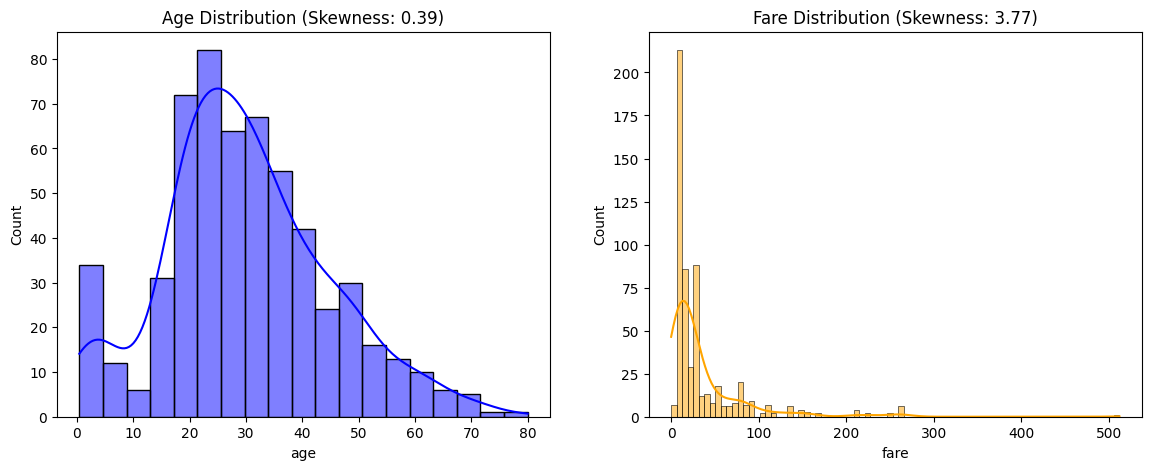

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# for 'age'
sns.histplot(X_train['age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Age Distribution (Skewness: {X_train["age"].skew():.2f})')

# for 'fare'
sns.histplot(X_train['fare'], kde=True, ax=axes[1], color='orange')
axes[1].set_title(f'Fare Distribution (Skewness: {X_train["fare"].skew():.2f})')

plt.show()

# in those charts i can clearly see that i dont need to change age but i have to work on fare to improve my model

##Step 2: The Log Transform (The Heavy Hitter)
The Log transform is the king of fixing right-skewed data. The fare column is heavily right-skewed (most fares are cheap, a few are wildly expensive).

Note: Log of 0 is undefined. Because some passengers rode for £0, we use np.log1p (which adds 1 to everything before logging) to prevent math errors.

--- Results for fare ---
Logistic Regression Accuracy: 61.54%
Decision Tree Accuracy:       62.94%



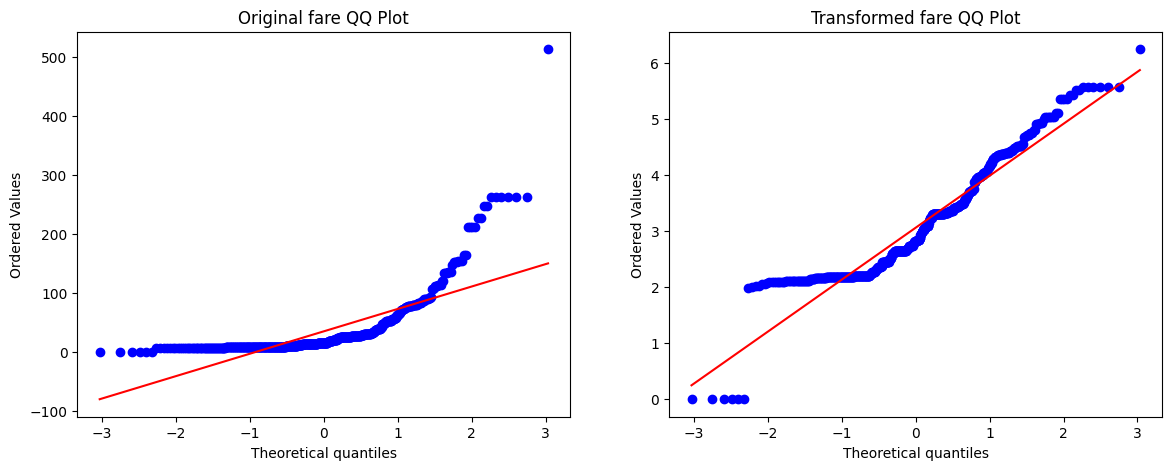

In [9]:
log_transformer = FunctionTransformer(func=np.log1p)

# test it on 'Fare' column
test_transformation(log_transformer, 'fare')

## Step 3: Square Root & Reciprocal
Different math functions crush outliers with varying levels of aggression.
- Square Root: Less aggressive than Log. Good
for mild skewness.
- Reciprocal ($1 / x$): Extremely aggressive. Reverses the order of large and small numbers.

Testing Square Root on Age:
--- Results for age ---
Logistic Regression Accuracy: 62.94%
Decision Tree Accuracy:       62.94%



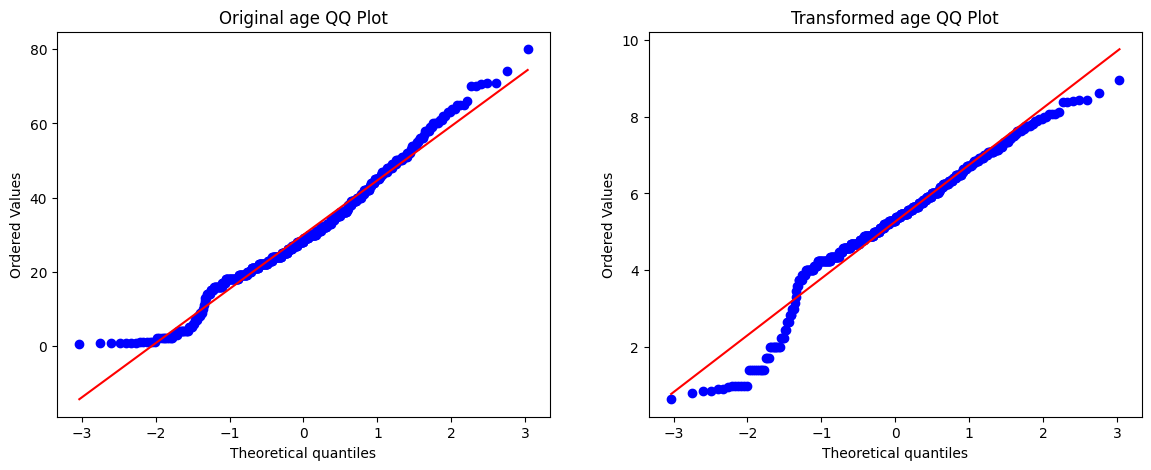

In [12]:
sqrt_transformer = FunctionTransformer(func=np.sqrt)
print("Testing Square Root on Age:")
test_transformation(sqrt_transformer, 'age')

# we can clearly see because age is already normal and we perform transformation it is actually not a good idea to perform this


Testing Reciprocal on Age:
--- Results for fare ---
Logistic Regression Accuracy: 60.14%
Decision Tree Accuracy:       63.64%



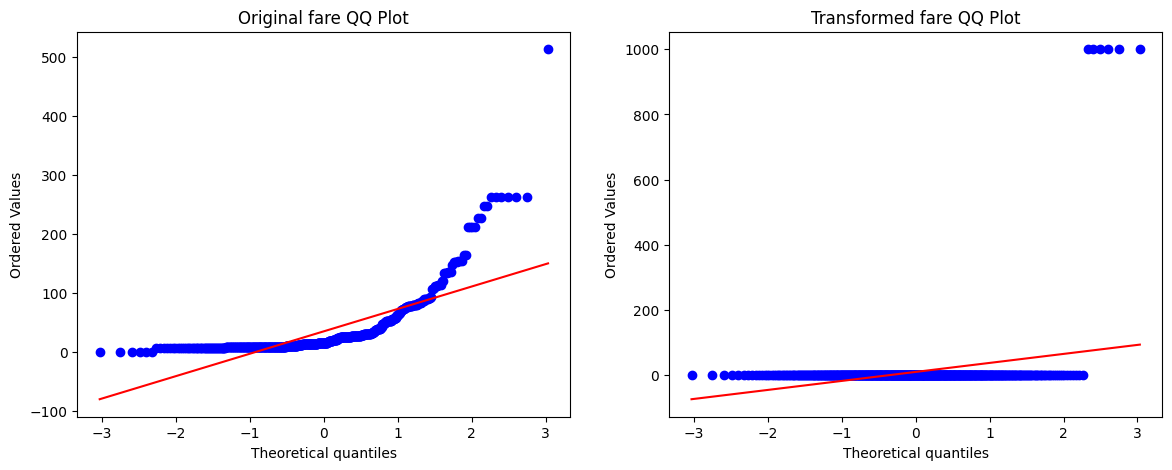

In [14]:
# let's do the reciprocal also and see the results on 'fare' and compare it will improve model or not
# We add a tiny number (0.001) to prevent dividing by zero!
reciprocal_transformer = FunctionTransformer(func=lambda x: 1 / (x + 0.001))
print("\nTesting Reciprocal on Age:")
test_transformation(reciprocal_transformer, 'fare')

# it is not performing good for 'fare' compare to the log1p

## Step 4: Square (For Left-Skewed Data)
Log, Sqrt, and Reciprocal are for Right-Skewed data (long tail points right).
If your data is Left-Skewed (long tail points left), those functions make it worse. To fix left-skewed data, we apply exponents, like Square.

Testing Square on Age:
--- Results for age ---
Logistic Regression Accuracy: 65.03%
Decision Tree Accuracy:       62.24%



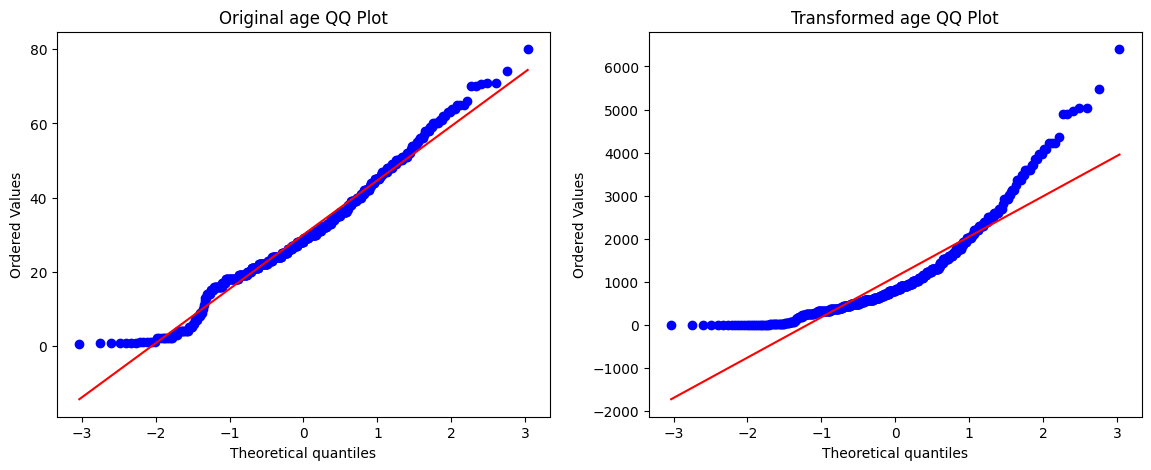

In [15]:
# Square Transformer
square_transformer = FunctionTransformer(func=np.square)
print("Testing Square on Age:")
test_transformation(square_transformer, 'age')

# naah original is still better

## Step 5: Custom Functions
The true power of FunctionTransformer is that you can invent your own logic. Let's say you want to create a feature that calculates a custom ratio or completely arbitrary math, and you want it pipeline-ready.

Testing Custom Logic on Fare:
--- Results for fare ---
Logistic Regression Accuracy: 61.54%
Decision Tree Accuracy:       62.94%



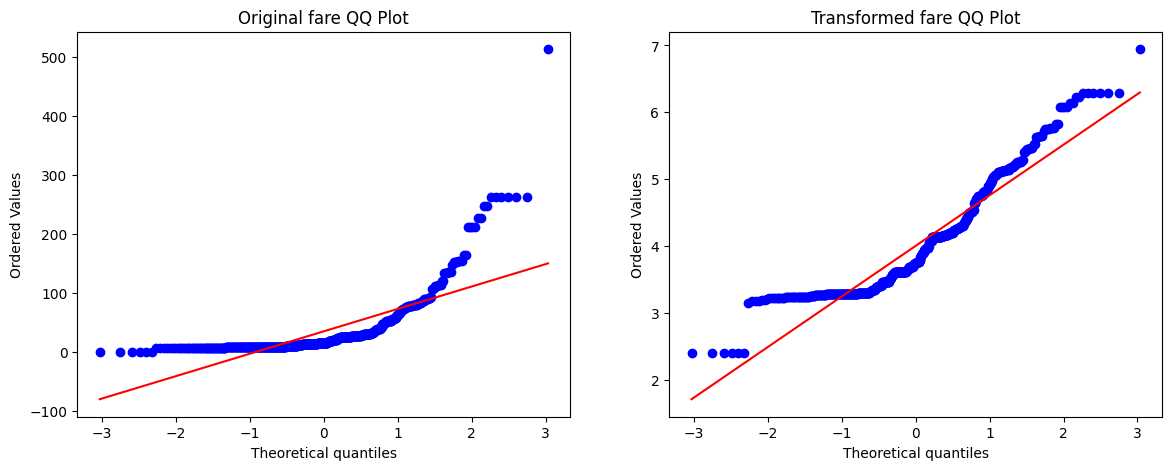

In [17]:
# Create a completely custom math function
def custom_math_logic(X):
    # Just an example: multiply by 2, add 10, then take the log
    return np.log1p((X * 2) + 10)

# Wrap it in the FunctionTransformer
custom_transformer = FunctionTransformer(func=custom_math_logic)

print("Testing Custom Logic on Fare:")
test_transformation(custom_transformer, 'fare')